In [49]:
import pandas as pd

df = pd.read_csv(r'C:\Users\oorko\OneDrive\Documents\projects\Finance\Customer Churn Prediction\WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Basic overview
print(df.shape)          # rows and columns
df.head()                # first 5 rows

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [3]:
df.isnull().sum() 

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df['Churn'].value_counts(normalize=True).mul(100).round(1)

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

In [6]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [7]:
print(df['Contract'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [8]:
print(df['InternetService'].value_counts())

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [9]:
print(df['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


C:\Users\oorko\AppData\Local\Temp\ipykernel_34632\2323842539.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['steelblue', 'salmon'])


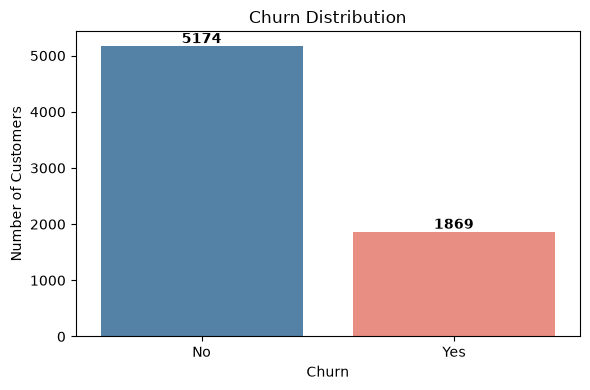

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many customers churned vs stayed
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Add the actual numbers on top of each bar
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

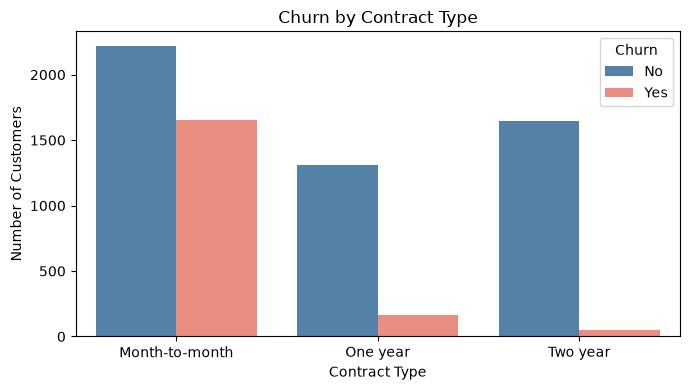

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue', 'salmon'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

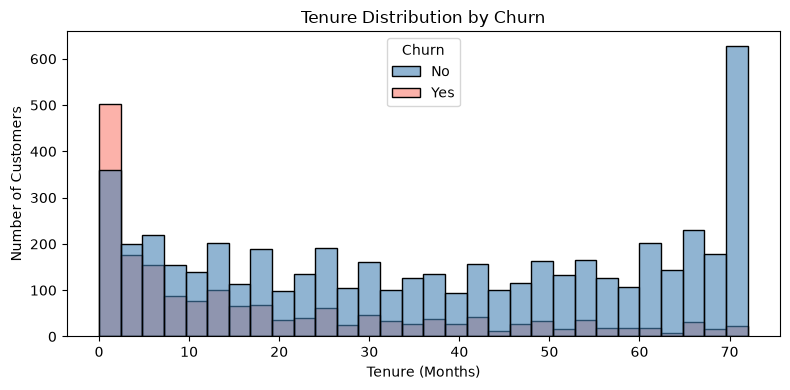

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue', 'salmon'], alpha=0.6)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

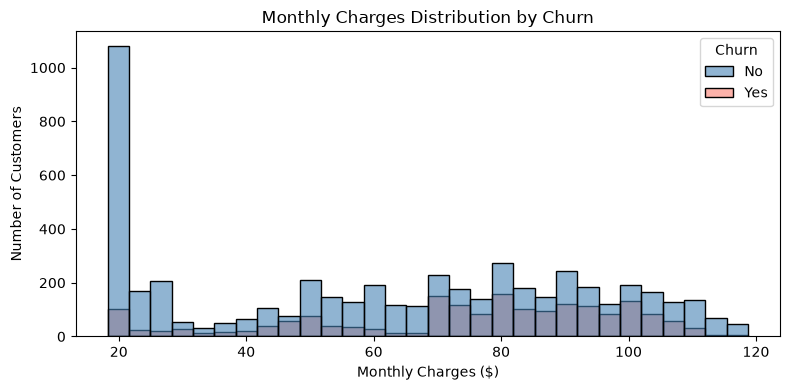

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, palette=['steelblue', 'salmon'], alpha=0.6)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

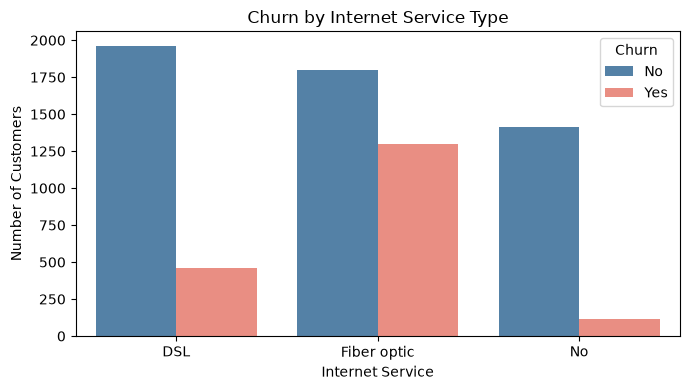

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['steelblue', 'salmon'])
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

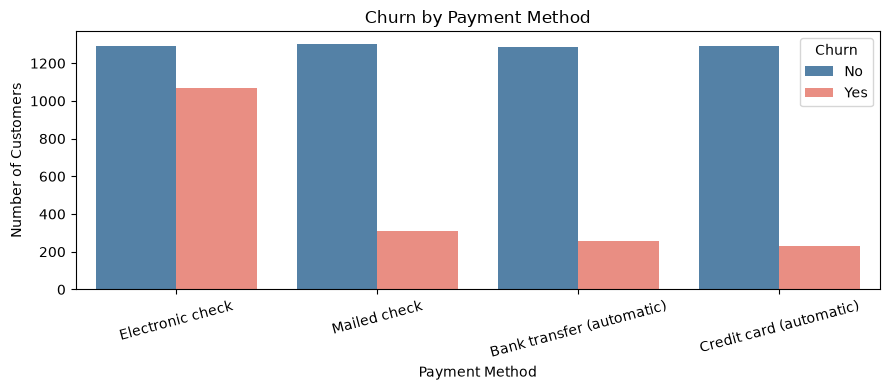

In [15]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['steelblue', 'salmon'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
# Replace blank spaces with NaN, then convert to number
df['TotalCharges'] = df['TotalCharges'].replace(' ', float('nan'))
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Verify it worked
print(df['TotalCharges'].dtype)

float64


In [17]:
df = df.dropna(subset=['TotalCharges'])

# Verify
print(df.shape)

(7032, 21)


In [18]:
df = df.drop(columns=['customerID'])

print(df.shape)

(7032, 20)


In [19]:
# These columns say "No internet service" or "No phone service" 
# which actually just means "No" — let's simplify them
cols_to_fix = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Verify one column
print(df['OnlineSecurity'].value_counts())

OnlineSecurity
No     5017
Yes    2015
Name: count, dtype: int64


In [20]:
# These are all the columns with just Yes/No values
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Also fix gender (Female=0, Male=1)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [21]:
# These columns have more than 2 categories
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

print(df.shape)
df.head()

(7032, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [22]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sum())  # should be 0
df.head()

(7032, 24)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [23]:
# X = everything the model learns FROM (features)
# y = what the model is trying to predict (target)

X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Churn rate:", y.mean().round(3))

X shape: (7032, 23)
y shape: (7032,)
Churn rate: 0.266


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5625
Testing rows: 1407


In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create a pipeline:
# 1. Scale the features
# 2. Train Logistic Regression
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        random_state=42
    )
)

# Train
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", round(accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.804

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.791

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", round(xgb_accuracy, 3))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.771

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



C:\Users\oorko\AppData\Local\Temp\ipykernel_34632\2946283096.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Blues_d')


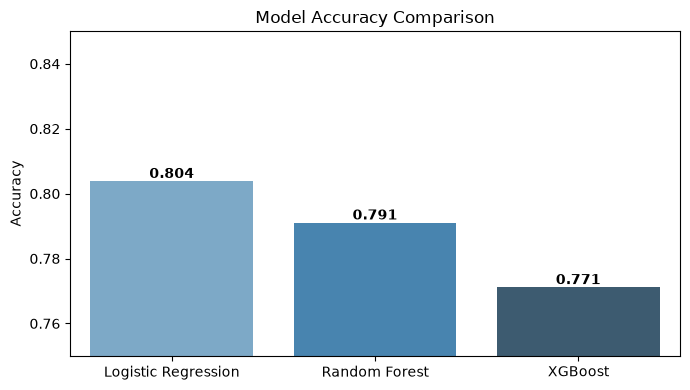

In [33]:
results = {
    'Logistic Regression': accuracy_score(y_test, lr_pred),
    'Random Forest': accuracy_score(y_test, rf_pred),
    'XGBoost': accuracy_score(y_test, xgb_pred)
}

plt.figure(figsize=(7, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.85)

for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [36]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Improved Logistic Regression
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=3000,
        random_state=42,
        class_weight="balanced"
    )
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("LR Accuracy:", round(accuracy_score(y_test, lr_pred), 3))
print(classification_report(y_test, lr_pred))


# Improved Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("RF Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print(classification_report(y_test, rf_pred))


# Improved XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

if positive_count == 0:
    raise ValueError("y_train contains no positive class values.")

scale = negative_count / positive_count

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGB Accuracy:", round(accuracy_score(y_test, xgb_pred), 3))
print(classification_report(y_test, xgb_pred))

LR Accuracy: 0.726
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

RF Accuracy: 0.761
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

XGB Accuracy: 0.753
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.69      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg    

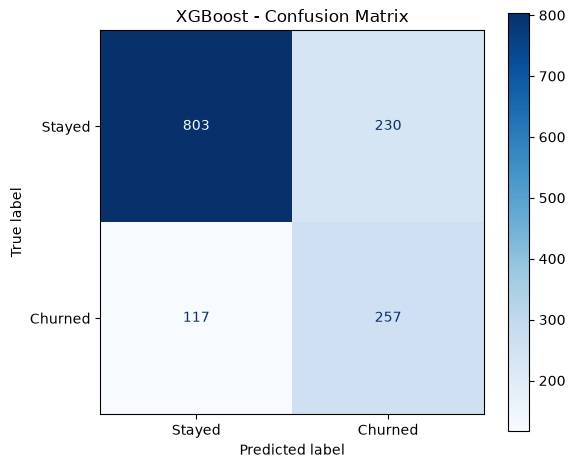

True Negatives (correctly predicted stayed): 803
False Positives (said churn, actually stayed): 230
False Negatives (said stay, actually churned): 117
True Positives (correctly predicted churn): 257


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.show()

print("True Negatives (correctly predicted stayed):", cm[0][0])
print("False Positives (said churn, actually stayed):", cm[0][1])
print("False Negatives (said stay, actually churned):", cm[1][0])
print("True Positives (correctly predicted churn):", cm[1][1])

In [38]:
from sklearn.metrics import roc_auc_score

lr_proba = lr_model.predict_proba(X_test)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f"Logistic Regression AUC: {lr_auc:.3f}")
print(f"Random Forest AUC:       {rf_auc:.3f}")
print(f"XGBoost AUC:             {xgb_auc:.3f}")

Logistic Regression AUC: 0.835
Random Forest AUC:       0.818
XGBoost AUC:             0.813


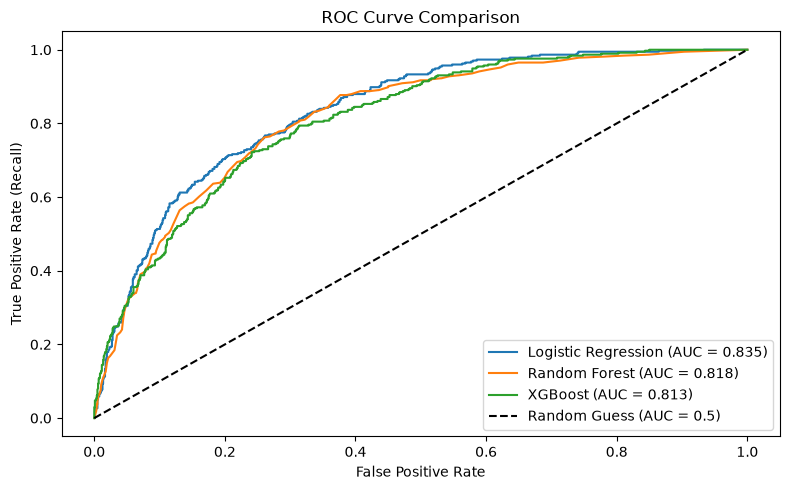

In [39]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 5))

for name, proba in [('Logistic Regression', lr_proba), 
                     ('Random Forest', rf_proba), 
                     ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
summary = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        round(accuracy_score(y_test, lr_pred), 3),
        round(accuracy_score(y_test, rf_pred), 3),
        round(accuracy_score(y_test, xgb_pred), 3)
    ],
    'AUC Score': [round(lr_auc, 3), round(rf_auc, 3), round(xgb_auc, 3)],
    'Churn Recall': [0.80, 0.65, 0.69]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

              Model  Accuracy  AUC Score  Churn Recall
Logistic Regression     0.726      0.835          0.80
      Random Forest     0.761      0.818          0.65
            XGBoost     0.753      0.813          0.69


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names and their importance scores
feature_names = X_train.columns
xgb_importance = xgb_model.feature_importances_

# Put into a dataframe and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))

                           Feature  Importance
19               Contract_Two year    0.330542
16     InternetService_Fiber optic    0.189466
18               Contract_One year    0.143734
17              InternetService_No    0.099638
12                 StreamingMovies    0.031207
11                     StreamingTV    0.016014
4                           tenure    0.015008
5                     PhoneService    0.014908
21  PaymentMethod_Electronic check    0.014232
7                   OnlineSecurity    0.012558


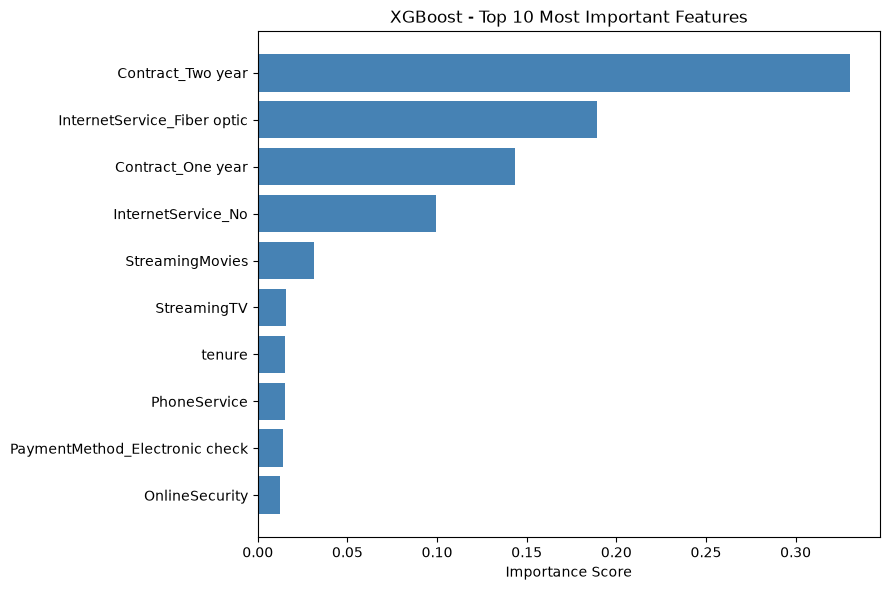

In [42]:
plt.figure(figsize=(9, 6))
plt.barh(
    importance_df['Feature'].head(10)[::-1],
    importance_df['Importance'].head(10)[::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title('XGBoost - Top 10 Most Important Features')
plt.tight_layout()
plt.show()

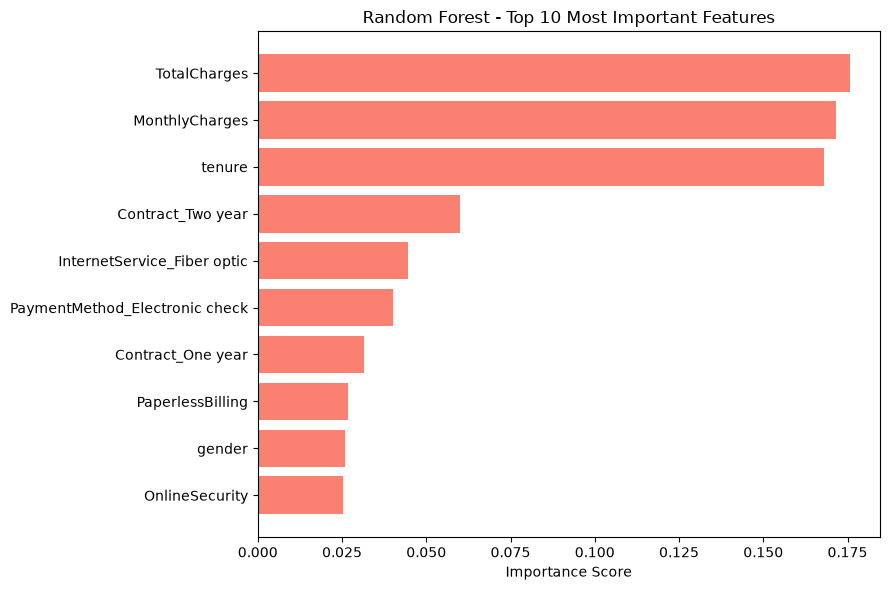

In [43]:
rf_importance = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(
    rf_importance_df['Feature'].head(10)[::-1],
    rf_importance_df['Importance'].head(10)[::-1],
    color='salmon'
)
plt.xlabel('Importance Score')
plt.title('Random Forest - Top 10 Most Important Features')
plt.tight_layout()
plt.show()

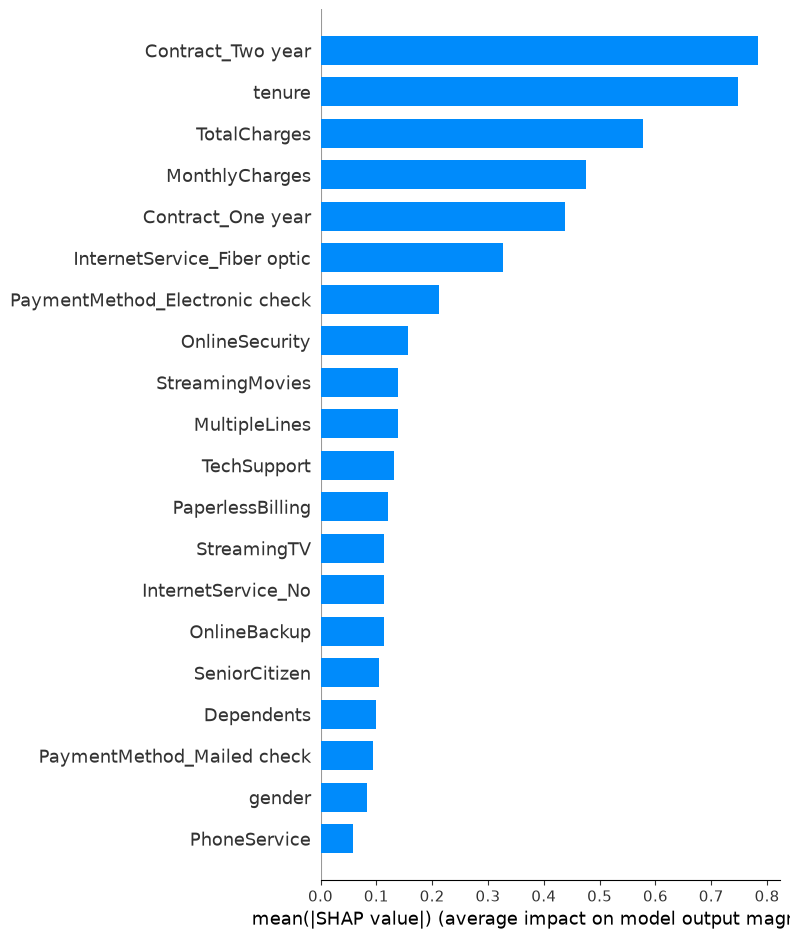

In [44]:
import subprocess
subprocess.run(['pip', 'install', 'shap', '--quiet'], capture_output=True)

import shap

# Create SHAP explainer using your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

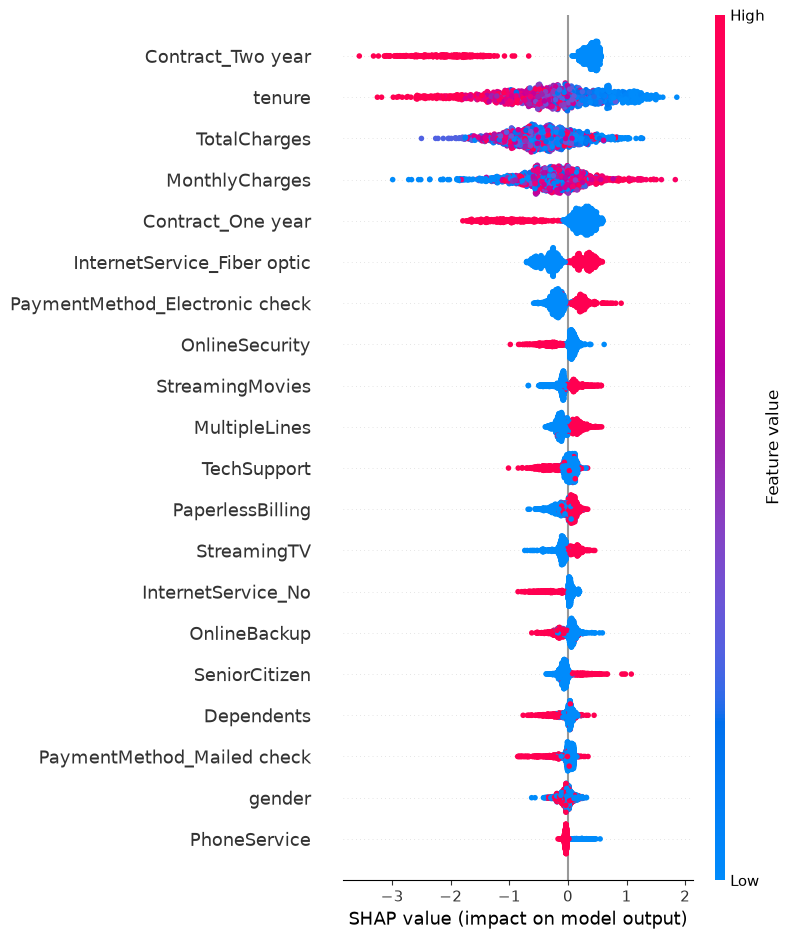

In [45]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=True)

In [48]:
from sklearn.metrics import roc_auc_score

print("=" * 50)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 50)

models = {
    'Logistic Regression': (lr_pred, lr_model.predict_proba(X_test)[:, 1]),
    'Random Forest':       (rf_pred, rf_model.predict_proba(X_test)[:, 1]),
    'XGBoost':             (xgb_pred, xgb_model.predict_proba(X_test)[:, 1])
}

for name, (pred, proba) in models.items():
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    report = classification_report(y_test, pred, output_dict=True)
    churn_recall = report['1']['recall']
    print(f"\n{name}")
    print(f"  Accuracy:      {acc:.3f}")
    print(f"  AUC Score:     {auc:.3f}")
    print(f"  Churn Recall:  {churn_recall:.3f}")

print("\n" + "=" * 50)
print("SELECTED MODEL: XGBoost (best AUC + churn recall balance)")
print("=" * 50)

MODEL PERFORMANCE SUMMARY

Logistic Regression
  Accuracy:      0.726
  AUC Score:     0.835
  Churn Recall:  0.797

Random Forest
  Accuracy:      0.761
  AUC Score:     0.818
  Churn Recall:  0.652

XGBoost
  Accuracy:      0.753
  AUC Score:     0.813
  Churn Recall:  0.687

SELECTED MODEL: XGBoost (best AUC + churn recall balance)
